In [1]:
import pandas as pd
import numpy as np


In [15]:
psy = pd.read_csv('./Youtube01-Psy.csv', usecols= ['CONTENT', 'CLASS'])
katyperry = pd.read_csv('./Youtube02-KatyPerry.csv', usecols= ['CONTENT', 'CLASS'])
lmfao = pd.read_csv('./Youtube03-LMFAO.csv', usecols= ['CONTENT', 'CLASS'])
eminem = pd.read_csv('./Youtube04-Eminem.csv', usecols= ['CONTENT', 'CLASS'])
shakira = pd.read_csv('./Youtube05-Shakira.csv', usecols= ['CONTENT', 'CLASS'])

In [16]:
print(psy.shape)
print(katyperry.shape)
print(lmfao.shape)
print(eminem.shape)
print(shakira.shape)

(350, 2)
(350, 2)
(438, 2)
(448, 2)
(370, 2)


In [17]:
data = pd.concat([psy, katyperry, lmfao, eminem, shakira], ignore_index=True)

In [18]:
data.shape

(1956, 2)

In [19]:
data.sample(13)

,CONTENT,CLASS
1834,CHECK OUT DANEJA GOOD GIRL,1
131,PSY GOT LOTS OF MONEY FROM YOUTUBE THAT HE GO...,0
1650,It was cool the best song ever ﻿,0
610,Also LuckyMusiqLive she probably could help u ...,1
1251,Anyone else notice that Megan Fox is in this v...,0
1392,thumb up if you watching in 2015 and you like...,0
446,"this video is very inaccurate, a tiger would r...",0
972,like this comment please﻿,1
602,this song never get's old &lt;3 ﻿,0
1254,Check Out The New Hot Video By Dante B Called ...,1


In [20]:
X = np.array(data['CONTENT'])
y = np.array(data['CLASS'])

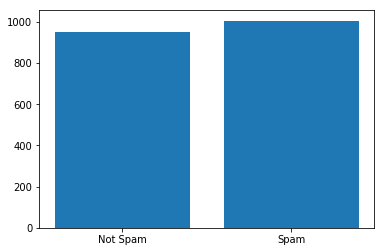

[ 951 1005]


In [21]:
import matplotlib.pyplot as plt

colors = np.array(["red",'#4CAF50'])
label=np.array(["Not Spam", "Spam"])
data = np.array([sum(y == 0),sum(y == 1)])
plt.bar(label,data)
            
plt.show()
data = np.array([sum(y == 0),sum(y == 1)])
print(data)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import pickle
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [23]:
 X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
vect=TfidfVectorizer()
Xtrain=vect.fit_transform(X_train)
X_test=vect.transform(X_test)
print("TfidfVectorizer model will saving")
pkl_filename = "Vect_Model.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(vect, file)

TfidfVectorizer model will saving


In [28]:
model=SVC()
model.fit(Xtrain,y_train)

SVC()

In [29]:
pred=model.predict(X_test)
acc=accuracy_score(y_test,pred)
print('Total Accuracy is : {}'.format(acc*100))


Total Accuracy is : 95.40816326530613


In [31]:
cm= confusion_matrix(y_test, pred)
cm

array([[173,   3],
       [ 15, 201]], dtype=int64)

In [33]:
report=classification_report(y_test,pred)
print(report)


              precision    recall  f1-score   support

           0       0.92      0.98      0.95       176
           1       0.99      0.93      0.96       216

    accuracy                           0.95       392
   macro avg       0.95      0.96      0.95       392
weighted avg       0.96      0.95      0.95       392



In [34]:
print("model will saving")
pkl_filename = "Model.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(model, file)

model will saving
